### **1.Consumo di alcol per paese** 
Esegui un’**analisi esplorativa** focalizzata sul **consumo di alcol**.  
Analizza i seguenti aspetti:
* Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)

* Calcola la media del consumo di birra, vino, e distillati

* Crea una nuova colonna alcohol_index che sia: `(beer_servings + wine_servings + spirit_servings) / 3`

* Trova il paese con il valore massimo di alcohol_index

* Filtra solo i paesi che consumano più di 100 birre all’anno

Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)

Crea un line plot con wine_servings ordinato per paese (usa sort_values)

['country', 'beer_servings', 'spirit_servings', 'wine_servings', 'total_litres_of_pure_alcohol', 'alcohol_index']


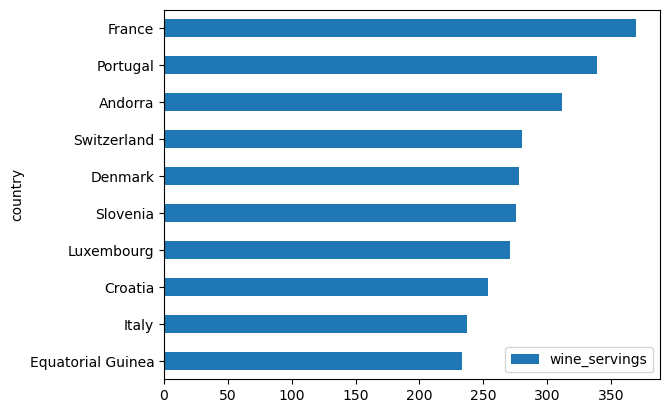

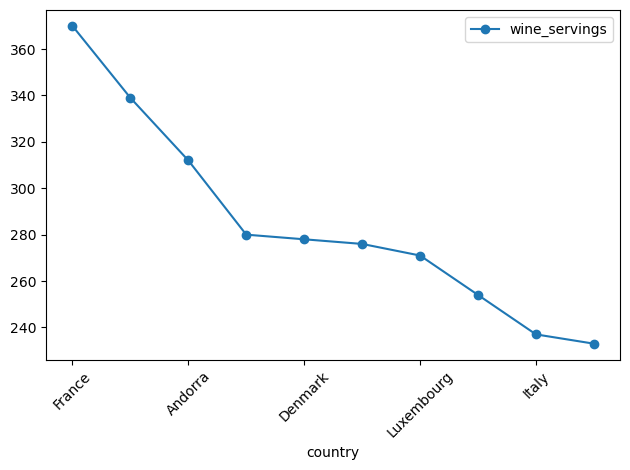

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset  
df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")
df.sort_values(by="total_litres_of_pure_alcohol", ascending = False)
df["beer_servings"].mean()
df["spirit_servings"].mean()
df["wine_servings"].mean()

df["alcohol_index"] = (df["beer_servings"] + df["spirit_servings"] + df["wine_servings"])/3
df

(df.groupby("country")["alcohol_index"].max()).sort_values(ascending=False)
df

df[df["beer_servings"] > 100]

df["total_litres_of_pure_alcohol"].sort_values(ascending=False).head(10)
#df[df.groupby("country")["wine_servings"].max().sort_values()]
print(df.columns.tolist())
df_sorted = df.sort_values(by="wine_servings", ascending=False) #inplace=True)
#print(df_sorted.head(10))

df_sorted.head(10).plot(x="country", y="wine_servings", kind="barh")
plt.gca().invert_yaxis()  # mette il valore più alto in cima
plt.show()

df_sorted.head(10).plot(x="country", y="wine_servings", kind="line", marker="o")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **2.Analisi offerte di lavoro** 

Esegui un’**analisi esplorativa** focalizzata sui **lavori nel campo dei dati in ciascun paese**.  
Analizza i seguenti aspetti per ogni paese:

* Lo **stipendio medio annuale** (`salary_year_avg`)
* Il **numero totale di offerte di lavoro** (job count)
* L’intervallo degli stipendi: **valore minimo e massimo** (`min` / `max`)

Rappresenta graficamente lo stipendio medio (`salary_year_avg`) per `job_title_short` usando un grafico a barre orizzontali. Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.

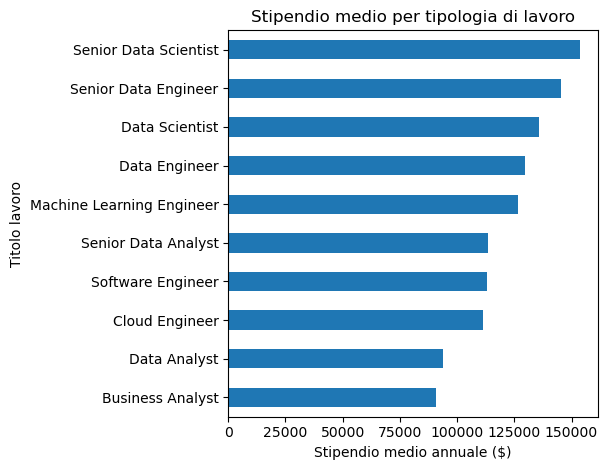

In [ ]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset["train"].to_pandas()
df.dropna(subset=["job_location", "salary_year_avg"], inplace=True)
# df
# print(df)

df.groupby("job_country")["salary_year_avg"].mean()

df["job_country"].value_counts()

df.sort_values(by="salary_year_avg", ascending=False, inplace=True)
intervallo =  df["salary_year_avg"].iloc[0] - df["salary_year_avg"].iloc[-1]
#intervallo = df["salary_year_avg"].max() - df["salary_year_avg"].min()
intervallo

analisi_paese = df.groupby("job_country")["salary_year_avg"].agg(
    stipendio_medio="mean",
    job_count="count",
    stipendio_min="min",
    stipendio_max="max"
)
analisi_paese

df_titoli = df.groupby("job_title_short")["salary_year_avg"].mean().sort_values(ascending=True)

df_titoli.plot(kind="barh")
plt.title("Stipendio medio per tipologia di lavoro")
plt.xlabel("Stipendio medio annuale")
plt.ylabel("Titolo lavoro")
plt.tight_layout()
plt.show()


### **3. Analisi vendite (dataset tips)**

Esegui un’**analisi esplorativa** focalizzata sulle **vendite giornaliere**.  
Analizza i seguenti aspetti per ogni giorno (`day`):

* Il **conto medio** (`total_bill`)
* Il **numero totale di osservazioni** (conteggio delle righe)
* Il **valore minimo e massimo** del conto (`total_bill` → `min` / `max`)

* Crea una nuova colonna `conto_per_persona` che sia:  
  `total_bill / size`

* Trova il giorno con il **conto medio più alto**

Rappresenta graficamente il **conto medio (`total_bill`) per giorno** usando un **grafico a barre**.  
Ordina i dati dal valore più alto al più basso.  
Aggiungi titolo ed etichette agli assi.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

df.head()

analisi_giornata = df.groupby("day")["total_bill"].agg(conto_medio = "mean",
    conteggio = "count",
    MAX = "max",
    min = "min")

print(analisi_giornata)

df["conto_per_persona"] = df["total_bill"]/df["size"]
# giorno_conto_max = (df.groupby("total_bill")["day"].max()).sort_values(ascending= False, inplace=True)
# giorno_conto_max
#analisi_giornata["MAX"].sort_values(ascending = False).head(1)

giorno_conto_max = analisi_giornata["conto_medio"].idxmax()
giorno_conto_max

      conto_medio  conteggio    MAX   min
day                                      
Fri     17.151579         19  40.17  5.75
Sat     20.441379         87  50.81  3.07
Sun     21.410000         76  48.17  7.25
Thur    17.682742         62  43.11  7.51


'Sun'